<a href="https://colab.research.google.com/github/SatyaUdisi/Titanic-Data-Cleaning-Project/blob/main/data_project_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Data Shape: (891, 12)
Cleaned Data Shape: (775, 11)


/tmp/ipykernel_2086/1343061702.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Pclass', y='Survived', data=df, palette='muted', errorbar=None)


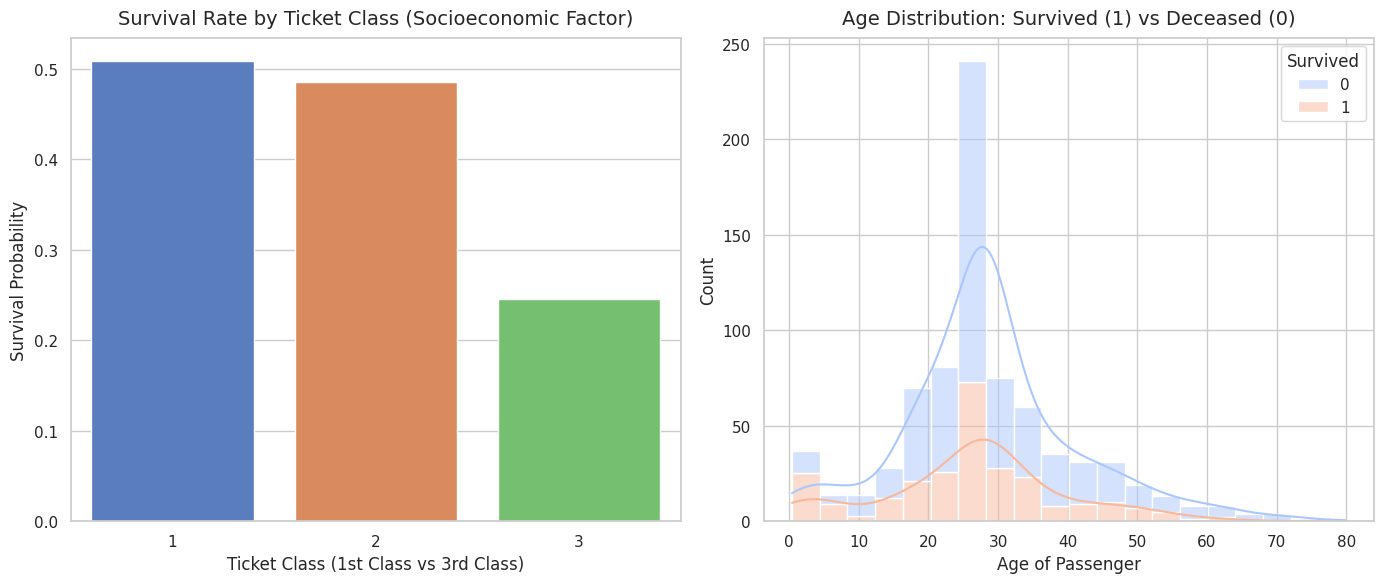

Dashboard created and saved successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: LOAD THE DATA
# ==========================================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Initial Data Shape:", df.shape)

# ==========================================
# STEP 2: DATA CLEANING
# ==========================================

# 1. Handle Missing Values
# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())
# Fill missing Embarked values with the mode (most common port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Drop 'Cabin' column because it has too many missing values (>70%)
df = df.drop(columns=['Cabin'])

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Handle Outliers (Filtering extreme Fares using IQR)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

print("Cleaned Data Shape:", df.shape)

# ==========================================
# STEP 3: DATA VISUALIZATION & STORYTELLING
# ==========================================
sns.set_theme(style="whitegrid")

# Create a 1-row, 2-column dashboard layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Survival Rate by Passenger Class (Tells the socioeconomic story)
sns.barplot(ax=axes[0], x='Pclass', y='Survived', data=df, palette='muted', errorbar=None)
axes[0].set_title('Survival Rate by Ticket Class (Socioeconomic Factor)', fontsize=14, pad=10)
axes[0].set_ylabel('Survival Probability')
axes[0].set_xlabel('Ticket Class (1st Class vs 3rd Class)')

# Chart 2: Age Distribution by Survival Status (Tells the demographic story)
sns.histplot(ax=axes[1], data=df, x='Age', hue='Survived', multiple='stack', palette='coolwarm', kde=True, bins=20)
axes[1].set_title('Age Distribution: Survived (1) vs Deceased (0)', fontsize=14, pad=10)
axes[1].set_xlabel('Age of Passenger')
axes[1].set_ylabel('Count')

# Tight layout to prevent overlapping text
plt.tight_layout()

# Save the combined dashboard as a single image file
plt.savefig('titanic_insights_dashboard.png', dpi=300)
plt.show()

print("Dashboard created and saved successfully!")